In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [23]:
data1 = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Regression.csv"
df = pd.read_csv(data1)
print(df.dtypes)

month_number           int64
year_val               int64
listing_tier          object
brand                 object
analytic_category     object
total_gmv            float64
avg_unit_price       float64
total_orders           int64
avg_delivery_days    float64
dtype: object


 New R2: 0.0001
 MAE: 356874.28

 Buisness inferences by category/brand/tier
                                Feature  Impact_on_GMV
5       brand_reduced_Flipkart SmartBuy   2.219640e+06
8           brand_reduced_HouseOfCommon   4.635834e+05
16             brand_reduced_ShopGlobal   3.165650e+05
33                   cat_reduced_Others   2.184628e+05
11                 brand_reduced_Others   1.607272e+05
27                 cat_reduced_Grooming   9.427718e+04
15                   brand_reduced_SYGA   8.280599e+04
20        brand_reduced_house of common   5.839408e+04
38  cat_reduced_WomenEthnicContemporary   4.838839e+04
32            cat_reduced_MensTopwearUB   4.356421e+04
GMV Trend analysis: 0.00


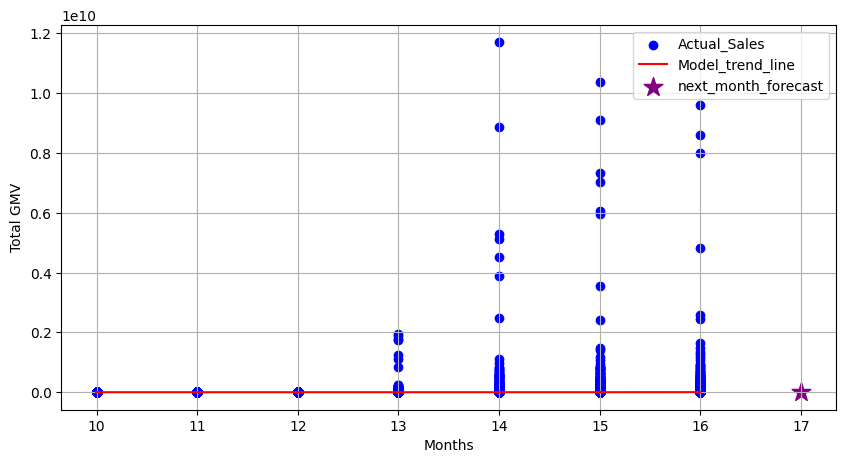

In [32]:
def limit_categories(df, column, top_n=20):
    top_values = df[column].value_counts().nlargest(top_n).index
    return df[column].where(df[column].isin(top_values), 'Others')
    
df['brand_reduced'] = limit_categories(df, 'brand', top_n=20)
df['cat_reduced'] =   limit_categories(df, 'analytic_category', top_n=20)


df['time_index'] = (df['year_val'] - df['year_val'].min())* 12 + df['month_number']
features_df = pd.get_dummies(df[['time_index','listing_tier','brand_reduced','cat_reduced']], drop_first=True)
X= features_df
y= df['total_gmv']

model = LinearRegression()
model.fit(X,y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f" New R2: {r2_score(y, y_pred):.4f}")
print(f" MAE: {mae:.2f}")

importance = pd.DataFrame({'Feature': X.columns, 'Impact_on_GMV': model.coef_})
importance = importance.sort_values(by='Impact_on_GMV', ascending = False)
print("\n Buisness inferences by category/brand/tier")
print(importance.head(10))


next_month_data = X.tail(1).copy()
next_month_data['time_index'] = X['time_index'].max()+1
future_prediction = model.predict(next_month_data)
next_month_index = next_month_data['time_index'].values


plt.figure(figsize=(10,5))
plt.scatter(df['time_index'], y, color= 'blue' , label ='Actual_Sales')
sorted_indices = df['time_index'].argsort()
plt.plot(df['time_index'].iloc[sorted_indices], y_pred[sorted_indices], color='red', label='Model_trend_line')
plt.scatter(next_month_data['time_index'], future_prediction, color='purple', s=200, marker= '*',label='next_month_forecast')
print(f"GMV Trend analysis: {r2:.2f}")
plt.xlabel("Months")
plt.ylabel("Total GMV")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
from sklearn.ensemble import RandomForestRegressor
def limit_categories(df, column, top_n=20):
    top_values = df[column].value_counts().nlargest(top_n).index
    return df[column].where(df[column].isin(top_values), 'Others')

df['Brand_reduced'] = limit_categories(df, 'brand', top_n=20)
df['cat_reduced'] = limit_categories(df, 'analytic_category', top_n=20)

feature_df = pd.get_dummies(df[['time_index','listing_tier', 'Brand_reduced', 'cat_reduced']], drop_first=True)
X= feature_df
y= df['total_gmv']


rf_model = RandomForestRegressor(n_estimators = 100, max_depth= 10, random_state=42)
rf_model.fit(X,y)
y_pred_rf = rf_model.predict(X)
r2_rf = r2_score(y, y_pred_rf)
print(f" Random Forest R2: {r2_rf:.2f}")


 Random Forest R2: 0.00


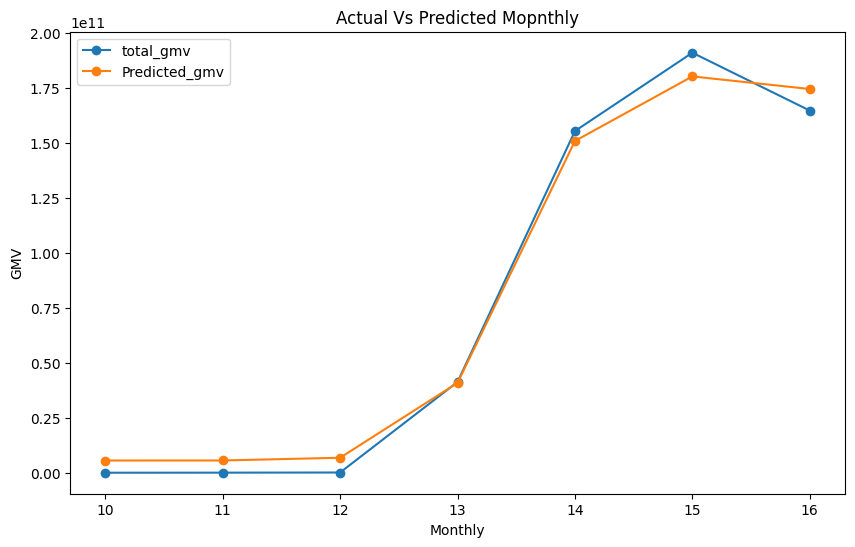

Forecast for the Month: 17: 170,583,210.59


In [42]:
from sklearn.ensemble import RandomForestRegressor
df_agg = df.groupby(['time_index', 'listing_tier', 'analytic_category']).agg({
    'total_gmv': 'sum'
}).reset_index()
X= pd.get_dummies(df_agg[['time_index', 'listing_tier', 'analytic_category']], drop_first=True)
y=df_agg['total_gmv']

model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=45)
model.fit(X,y)
df_agg['Predicted_gmv'] = model.predict(X)

next_month = X.tail(1).copy()
next_month['time_index'] = X['time_index'].max() +1
forecast_val = model.predict(next_month)

final_trend = df_agg.groupby('time_index')[['total_gmv', 'Predicted_gmv']].sum()
final_trend.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Actual Vs Predicted Mopnthly")
plt.xlabel("Monthly")
plt.ylabel("GMV")
plt.show()

print(f"Forecast for the Month: {X['time_index'].max() +1}: {forecast_val[0]:,.2f}")


    

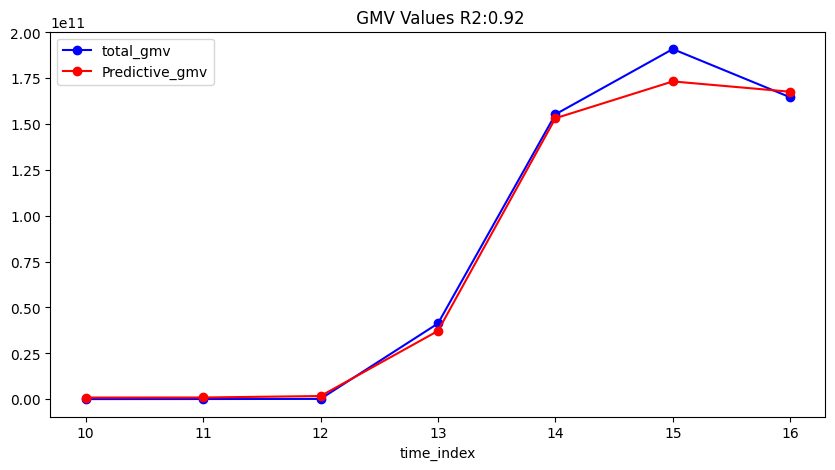

 R2: 0.9190 | MAE: 137,351,110.85 | Forecast: 179,040,051.33


In [46]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

df_agg = df.groupby(['time_index','listing_tier', 'analytic_category']).agg({'total_gmv': 'sum'}).reset_index()
X = pd.get_dummies(df_agg[['time_index','listing_tier', 'analytic_category']], drop_first=True)
y = df_agg['total_gmv']

model = RandomForestRegressor(n_estimators=50, max_depth =10, random_state=42)
model.fit(X,y)
df_agg['Predictive_gmv'] = model.predict(X)

r2 = r2_score(y,df_agg['Predictive_gmv'])
mae = mean_absolute_error(y, df_agg['Predictive_gmv'])

next_month = X.tail(1).copy()
next_month['time_index'] = X['time_index'].max() +1
forecast_val = model.predict(next_month)[0]

final_trend = df_agg.groupby('time_index')[['total_gmv', 'Predictive_gmv']].sum()
final_trend.plot(kind= 'line', marker = 'o', figsize=(10,5), color= ['blue', 'red'])

plt.title(f" GMV Values R2:{r2:,.2f}")
plt.show()

print(f" R2: {r2:.4f} | MAE: {mae:,.2f} | Forecast: {forecast_val:,.2f}")




 Top Impact Columns
time_index                                   0.417920
listing_tier_NONE                            0.289934
analytic_category_Mobile                     0.215658
analytic_category_Gourmet                    0.022036
analytic_category_Grooming                   0.016324
analytic_category_Television                 0.006497
analytic_category_Laptops                    0.005225
analytic_category_Refrigerator               0.005221
analytic_category_WomenEthnicContemporary    0.004985
analytic_category_Seasonal                   0.003970
dtype: float64


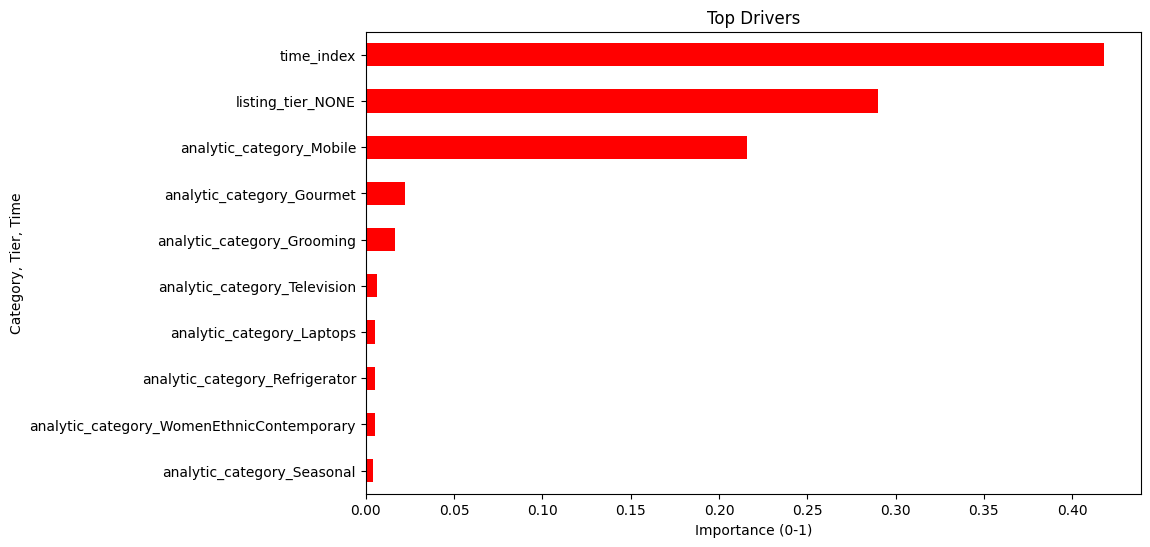

In [56]:
importances = pd.Series(model.feature_importances_ , index=X.columns)
top_impact = importances.sort_values(ascending=False).head(10)

print(" Top Impact Columns")
print(top_impact)

top_impact.plot(kind= 'barh', figsize=(10,6), color= 'red')
plt.title("Top Drivers")
plt.xlabel("Importance (0-1)")
plt.ylabel("Category, Tier, Time")
plt.gca().invert_yaxis()
plt.show()

In [58]:
summary_table = final_trend.copy()
forecast_row = pd.DataFrame({
    'time_index': [X['time_index'].max() +1],
    'total_gmv': [np.nan],
    'Predicted_gmv': [forecast_val]
}).reset_index()
full_summary =pd.concat([summary_table, forecast_row])
print(full_summary)

       total_gmv  Predictive_gmv  index  time_index  Predicted_gmv
10  2.821538e+06    8.499058e+08    NaN         NaN            NaN
11  3.320212e+07    8.661483e+08    NaN         NaN            NaN
12  1.027341e+08    1.665183e+09    NaN         NaN            NaN
13  4.124539e+10    3.717906e+10    NaN         NaN            NaN
14  1.553020e+11    1.531699e+11    NaN         NaN            NaN
15  1.908976e+11    1.732610e+11    NaN         NaN            NaN
16  1.645972e+11    1.676252e+11    NaN         NaN            NaN
0            NaN             NaN    0.0        17.0   1.790401e+08
